In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pypsa
import pandas as pd
from pathlib import Path

idx = pd.IndexSlice

In [54]:
# --- Sector grouping ---
# Map raw carrier names to ~10 high-level sectors
SECTOR_MAP = {
    # Renewable power
    "solar-hsat": "renewable power",
    "Solar": "renewable power",
    "solar": "renewable power",
    "Onshore Wind": "renewable power",
    "onwind": "renewable power",
    "Offshore Wind (AC)": "renewable power",
    "Offshore Wind (DC)": "renewable power",
    "Offshore Wind (Floating)": "renewable power",
    "offwind-ac": "renewable power",
    "offwind-dc": "renewable power",
    "offwind-float": "renewable power",
    "Reservoir & Dam": "renewable power",
    "Run of River": "renewable power",
    "Pumped Hydro Storage": "renewable power",
    "ror": "renewable power",
    "PHS": "renewable power",
    "hydro": "renewable power",
    # Fossil power
    "Combined-Cycle Gas": "fossil power",
    "Open-Cycle Gas": "fossil power",
    "CCGT": "fossil power",
    "OCGT": "fossil power",
    "OCGT methanol": "fossil power",
    "coal": "fossil power",
    "lignite": "fossil power",
    "nuclear": "fossil power",
    "oil": "fossil power",
    # Electricity grid & storage
    "electricity distribution grid": "electricity grid & storage",
    "AC": "electricity grid & storage",
    "DC": "electricity grid & storage",
    "Battery Storage": "electricity grid & storage",
    "battery charger": "electricity grid & storage",
    "battery discharger": "electricity grid & storage",
    "battery storage": "electricity grid & storage",
    "home battery": "electricity grid & storage",
    "home battery charger": "electricity grid & storage",
    "home battery discharger": "electricity grid & storage",
    "transmission lines": "electricity grid & storage",
    # Building heat
    "urban decentral gas boiler": "building heat",
    "urban decentral air heat pump": "building heat",
    "urban decentral biomass boiler": "building heat",
    "urban decentral oil boiler": "building heat",
    "urban decentral resistive heater": "building heat",
    "urban decentral solar thermal": "building heat",
    "rural gas boiler": "building heat",
    "rural ground heat pump": "building heat",
    "rural air heat pump": "building heat",
    "rural biomass boiler": "building heat",
    "rural oil boiler": "building heat",
    "rural resistive heater": "building heat",
    "rural solar thermal": "building heat",
    "urban central gas boiler": "building heat",
    "urban central air heat pump": "building heat",
    "urban central resistive heater": "building heat",
    "urban central solar thermal": "building heat",
    "urban central solid biomass CHP": "building heat",
    "urban central solid biomass CHP CC": "building heat",
    "urban central gas CHP": "building heat",
    "urban central gas CHP CC": "building heat",
    # Industry heat
    "heat<100 industry industrial heat pump medium temperature": "industry heat",
    "heat100-200 industry industrial heat pump high temperature": "industry heat",
    "heat200-500 industry solid biomass": "industry heat",
    "heat<100 industry solid biomass": "industry heat",
    "heat100-200 industry solid biomass": "industry heat",
    "heat100-200 industry gas": "industry heat",
    "heat<100 industry gas": "industry heat",
    "heat>500 industry gas": "industry heat",
    "heat200-500 industry gas": "industry heat",
    "heat<100 industry electric boiler steam": "industry heat",
    "heat100-200 industry electric boiler steam": "industry heat",
    "heat>500 industry hydrogen": "industry heat",
    "heat200-500 industry hydrogen": "industry heat",
    # Steel & heavy industry
    "BOF": "steel & heavy industry",
    "EAF": "steel & heavy industry",
    "H2 DRI": "steel & heavy industry",
    "gas DRI": "steel & heavy industry",
    "HVC to air": "steel & heavy industry",
    "non-sequestered HVC": "steel & heavy industry",
    "naphtha for industry": "steel & heavy industry",
    "coal for industry": "steel & heavy industry",
    "gas for industry": "steel & heavy industry",
    "gas for industry CC": "steel & heavy industry",
    "solid biomass for industry": "steel & heavy industry",
    "solid biomass for industry CC": "steel & heavy industry",
    "industry wood": "steel & heavy industry",
    # Hydrogen & synfuels
    "H2 Electrolysis": "hydrogen & synfuels",
    "H2 Store": "hydrogen & synfuels",
    "H2 Fuel Cell": "hydrogen & synfuels",
    "H2 pipeline": "hydrogen & synfuels",
    "H2 pipeline retrofitted": "hydrogen & synfuels",
    "SMR": "hydrogen & synfuels",
    "SMR CC": "hydrogen & synfuels",
    "Fischer-Tropsch": "hydrogen & synfuels",
    "methanolisation": "hydrogen & synfuels",
    "biomass-to-methanol": "hydrogen & synfuels",
    "biomass to liquid": "hydrogen & synfuels",
    "Sabatier": "hydrogen & synfuels",
    "methanol": "hydrogen & synfuels",
    "Haber-Bosch": "hydrogen & synfuels",
    "ammonia cracker": "hydrogen & synfuels",
    "ammonia store": "hydrogen & synfuels",
    # Gas & biogas infrastructure
    "biogas to gas": "gas & biogas",
    "gas pipeline": "gas & biogas",
    "gas pipeline new": "gas & biogas",
    "gas": "gas & biogas",
    # Transport
    "land transport oil": "transport",
    "BEV charger": "transport",
    "EV battery": "transport",
    "V2G": "transport",
    "kerosene for aviation": "transport",
    "shipping oil": "transport",
    "shipping methanol": "transport",
    # CO2 management
    "co2 stored": "CO2 management",
    "co2 sequestered": "CO2 management",
    "CO2 pipeline": "CO2 management",
    "co2 Store": "CO2 management",
}

# --- Demand-side sector grouping (by bus carrier) ---
BUS_CARRIER_SECTOR_MAP = {
    "AC": "electricity",
    "low voltage": "electricity",
    "urban central heat": "building heat",
    "urban decentral heat": "building heat",
    "residential urban decentral heat": "building heat",
    "services urban decentral heat": "building heat",
    "rural heat": "building heat",
    "residential rural heat": "building heat",
    "services rural heat": "building heat",
    "heat<100 industry": "industry heat",
    "heat100-200 industry": "industry heat",
    "heat200-500 industry": "industry heat",
    "heat>500 industry": "industry heat",
    "gas": "gas",
    "gas for industry": "gas",
    "H2": "hydrogen",
    "oil": "oil & transport",
    "oil primary": "oil & transport",
    "kerosene for aviation": "oil & transport",
    "shipping oil": "oil & transport",
    "shipping methanol": "oil & transport",
    "methanol": "synfuels",
    "NH3": "synfuels",
    "naphtha for industry": "synfuels",
    "solid biomass": "biomass",
    "solid biomass for industry": "biomass",
    "biogas": "biomass",
    "coal": "coal",
    "coal for industry": "coal",
    "lignite": "coal",
    "co2": "CO2",
    "co2 stored": "CO2",
    "co2 sequestered": "CO2",
    "uranium": "electricity",
    "steel": "industry process",
    "hbi": "industry process",
    "non-sequestered HVC": "industry process",
}


In [49]:
c = n.statistics.capex()
o = n.statistics.opex()
hc = hn.statistics.capex()
ho = hn.statistics.opex()
cap = n.statistics.optimal_capacity()
hcap = hn.statistics.optimal_capacity()

In [36]:
union = c.index.union(o.index)
total  = (c.reindex(union).replace(np.nan, 0) + o.reindex(union).replace(np.nan, 0))
hunion = hc.index.union(ho.index)
htotal = (hc.reindex(hunion).replace(np.nan, 0) + ho.reindex(hunion).replace(np.nan, 0))
diff_c = hc - c

In [35]:
diff = htotal - total
diff.sort_values()

component  carrier              
Generator  gas                     -4.872937e+10
           co2-ets                 -1.290630e+10
Link       urban central gas CHP   -3.241517e+09
           Combined-Cycle Gas      -2.855477e+09
           SMR                     -1.140903e+09
                                        ...     
Generator  Onshore Wind             1.036673e+10
Store      Battery Storage          1.059280e+10
Generator  Offshore Wind (DC)       1.604330e+10
           solar-hsat               2.079636e+10
           oil primary              4.858224e+10
Length: 124, dtype: float64

In [53]:
diff = hcap - cap
diff.sort_values().droplevel(0).sort_values()

carrier
gas                        -5.309776e+05
gas pipeline new           -8.977177e+04
urban central gas CHP      -6.836360e+04
urban central gas boiler   -4.757985e+04
SMR                        -1.672091e+04
                                ...     
methanol                    4.947746e+05
H2 Store                    5.390886e+05
Battery Storage             8.174951e+05
HVC to air                  2.879553e+06
ammonia store               4.289900e+06
Length: 125, dtype: float64

In [74]:
path = str(Path.cwd().parent / 'results' / 'networks' / 'base_s_50__3H-T-H-B-I-A-dist1_2030_free_{}{}.nc')

n = pypsa.Network(path.format(3500, ''))
hn = pypsa.Network(path.format(3500, '_50'))

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_3500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_3500_50.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [75]:
def get_demand_expenditure(n):
    """
    Compute demand-side expenditure by bus carrier sector in bn EUR/a.

    Only considers Load components (n.loads). For each load, retrieves
    its time series from n.loads_t.p_set (time-varying) or n.loads.p_set
    (static), then folds over the marginal price at the load's bus.

    expenditure = Σ_t (load_p × marginal_price_at_bus × snapshot_weight)
    """
    weights = n.snapshot_weightings.generators
    expenditures = {}

    for load_name, load_row in n.loads.iterrows():
        bus = load_row.bus
        bus_carrier = n.buses.at[bus, "carrier"]

        # Get load time series
        if load_name in n.loads_t.p_set.columns:
            load_ts = n.loads_t.p_set[load_name]
        else:
            load_ts = pd.Series(load_row.p_set, index=n.snapshots)

        # Get marginal price at the load's bus
        if bus in n.buses_t.marginal_price.columns:
            price_ts = n.buses_t.marginal_price[bus]
        else:
            continue

        # Expenditure = Σ_t (load × price × weight)
        expenditure = (load_ts * price_ts * weights).sum() / 1e9  # bn EUR
        # sector = BUS_CARRIER_SECTOR_MAP.get(bus_carrier, "other")
        sector = bus_carrier

        expenditures[sector] = expenditures.get(sector, 0.0) + expenditure

    return pd.Series(expenditures)

In [76]:
normal_expenditure = get_demand_expenditure(n)
hike_expenditure = get_demand_expenditure(hn)
df = pd.concat([normal_expenditure.rename('normal'), hike_expenditure.rename('hike')], axis=1)
df['diff'] = df['hike'] - df['normal']

In [77]:
df.sort_values('diff', ascending=False)

,normal,hike,diff
urban decentral heat,79.599911,118.164805,38.564894
rural heat,38.791708,52.189596,13.397888
land transport oil,168.214636,168.282824,0.068188
naphtha for industry,48.071036,48.096546,0.025509
kerosene for aviation,49.536518,49.556335,0.019818
shipping oil,32.738820,32.752137,0.013318
coal for industry,3.848436,3.851364,0.002928
agriculture machinery oil,3.424295,3.425680,0.001385
industry methanol,0.000000,0.000000,0.000000
process emissions,0.000000,0.000000,0.000000


In [90]:
eb = n.statistics.supply()
eb.index = eb.index.droplevel(0)
heb = hn.statistics.supply()
heb.index = heb.index.droplevel(0)

In [92]:
eb

carrier
Pumped Hydro Storage    7.429917e+07
Reservoir & Dam         3.314308e+08
rural heat vent         2.400000e-04
electricity             2.536382e+04
AC                      1.019133e+09
                            ...     
home battery            6.268310e+04
methanol                9.441043e+04
non-sequestered HVC     8.537197e+08
solid biomass import    2.484341e+03
uranium                 3.652600e-01
Length: 121, dtype: float64

In [91]:
((heb - eb).sort_values() / 1e6).dropna().astype(int).head(30)

carrier
gas                                  -2771
coal                                  -394
urban decentral air heat pump         -147
lignite                               -139
lignite                               -116
forest residues                       -111
coal                                  -103
urban decentral biomass boiler         -86
lignite                                -85
electricity distribution grid          -79
coal                                   -71
lignite                                -62
rural biomass boiler                   -54
urban central gas CHP                  -41
industry wood                          -41
rural ground heat pump                 -31
gas                                    -19
solid biomass                          -11
urban decentral resistive heater       -10
gas pipeline new                        -9
urban decentral gas boiler              -4
rural gas boiler                        -4
landscape care                          -3
rur

In [99]:
eb = n.statistics.supply(groupby=["bus_carrier", 'carrier'])
eb.index = eb.index.droplevel(0)
heb = hn.statistics.supply(groupby=["bus_carrier", 'carrier'])
heb.index = heb.index.droplevel(0)

In [116]:
'fsff' in 'fd fiuds dfsdvh'

False

In [112]:
n.buses_t.marginal_price

Bus,AL0 0,AL0 0 BOF emission,AL0 0 EV battery,AL0 0 H2,AL0 0 agriculture machinery oil,AL0 0 battery,AL0 0 biogas,AL0 0 co2 sequestered,AL0 0 co2 stored,AL0 0 gas,...,XK0 0 process emissions,XK0 0 rural heat,XK0 0 shipping oil,XK0 0 solid biomass,XK0 0 solid biomass for industry,XK0 0 steel,XK0 0 unsustainable bioliquids,XK0 0 urban central heat,XK0 0 urban decentral heat,co2 atmosphere
snapshot,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,64.615710,-40.00026,73.989425,49.802719,66.589921,64.831865,5.468573,-0.231191,-0.240803,22.166646,...,0.0,31.051955,0.0,13.657787,13.667821,379.078170,0.0,20.956135,58.403749,-39.990957
2024-01-01 03:00:00,64.615634,-40.00026,73.989555,49.792599,66.589922,64.337707,5.438726,-0.229513,-0.239126,22.176338,...,0.0,31.042081,0.0,13.657785,13.667819,379.069897,0.0,20.944727,56.467499,-39.990957
2024-01-01 06:00:00,64.615343,-40.00026,73.989668,49.782738,66.589922,63.577545,5.427573,-0.227780,-0.237392,22.178834,...,0.0,31.034742,0.0,13.657782,13.667816,379.396587,0.0,20.843610,50.993021,-39.990957
2024-01-01 09:00:00,58.871273,-40.00026,67.464722,49.773147,66.589922,61.157232,5.412736,-0.226019,-0.235632,22.179341,...,0.0,31.023555,0.0,13.657781,13.667815,376.405389,0.0,20.560081,36.592130,-39.990957
2024-01-01 12:00:00,58.870557,-40.00026,67.464881,49.763628,66.589922,61.122771,5.405078,-0.224582,-0.234194,22.179864,...,0.0,31.018878,0.0,13.657780,13.667814,376.453689,0.0,20.426700,34.437092,-39.990957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 09:00:00,53.949788,-40.00026,73.988439,49.857125,66.589922,56.559191,5.425113,-0.239431,-0.249043,22.563417,...,0.0,31.432681,0.0,13.657774,13.667808,375.404004,0.0,18.667861,44.029326,-39.990957
2024-12-31 12:00:00,51.837934,-40.00026,73.988609,49.845972,66.589922,56.432161,5.426136,-0.237579,-0.247191,22.557876,...,0.0,31.420557,0.0,13.657774,13.667809,374.243563,0.0,19.922983,37.266203,-39.990957
2024-12-31 15:00:00,64.615612,-40.00026,73.988954,49.834753,66.589922,63.749898,5.470617,-0.236080,-0.245692,22.558078,...,0.0,31.563308,0.0,13.657777,13.667811,379.869729,0.0,21.307470,60.749792,-39.990957


In [107]:
eb.loc['urban decentral heat'].mul(1e-6)

carrier
urban decentral air heat pump       523.169942
urban decentral biomass boiler      322.102490
urban decentral gas boiler          642.615376
urban decentral oil boiler           75.967197
urban decentral resistive heater     15.323516
urban decentral solar thermal         0.000868
dtype: float64

In [108]:
heb.loc['urban decentral heat'].mul(1e-6)

carrier
urban decentral air heat pump       376.094682
urban decentral biomass boiler      236.006485
urban decentral gas boiler          638.468495
urban decentral oil boiler          323.786707
urban decentral resistive heater      5.007948
urban decentral solar thermal         0.000701
dtype: float64

In [ ]:
eb.loc[idx'']

component    bus_carrier         
StorageUnit  AC                      4.057300e+08
             rural heat              2.400000e-04
Load         low voltage             2.536382e+04
Line         AC                      1.019133e+09
Link         AC                      1.015982e+09
                                         ...     
Store        home battery            6.268310e+04
             methanol                9.441043e+04
             non-sequestered HVC     8.537197e+08
             solid biomass import    2.484341e+03
             uranium                 3.652600e-01
Length: 61, dtype: float64

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

,normal,hike
low voltage,175.234220,178.240741
EV battery,12.242411,10.629185
land transport oil,168.214636,168.282247
urban central heat,17.255565,26.218092
heat<100 industry,10.090870,9.100092
heat100-200 industry,11.703098,9.961918
heat200-500 industry,3.186961,4.191668
heat>500 industry,9.960711,24.264602
solid biomass for industry,6.958329,7.908091
steel,31.093531,28.544390


In [ ]:
path = str(Path.cwd().parent / 'results' / 'networks' / 'base_s_50__3H-T-H-B-I-A-dist1_2030_free_{}{}.nc')

data = list()
for wiggle in (wiggles := [500, 1250, 2000, 2750, 3500]):

    n = pypsa.Network(path.format(wiggle, ''))
    hn = pypsa.Network(path.format(wiggle, '_50'))

    normal_opex = n.statistics.opex().sum() * 1e-9
    normal_capex = n.statistics.capex().sum() * 1e-9
    hike_opex = hn.statistics.opex().sum() * 1e-9
    hike_capex = hn.statistics.capex().sum() * 1e-9

    data.append({
        'wiggle': wiggle,
        'normal_opex': normal_opex,
        'normal_capex': normal_capex,
        'hike_opex': hike_opex,
        'hike_capex': hike_capex,
        'diff_opex': hike_opex - normal_opex,
        'diff_capex': hike_capex - normal_capex,
    })

df = pd.DataFrame(data)


INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_500_50.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_1250.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_1250_50.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_2000_50.nc has buses, carriers, generators, global

In [6]:
# n = pypsa.Network(path.format(500, ''))
hn = pypsa.Network(path.format(500, '_50'))

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_500_50.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


<Axes: xlabel='snapshot'>

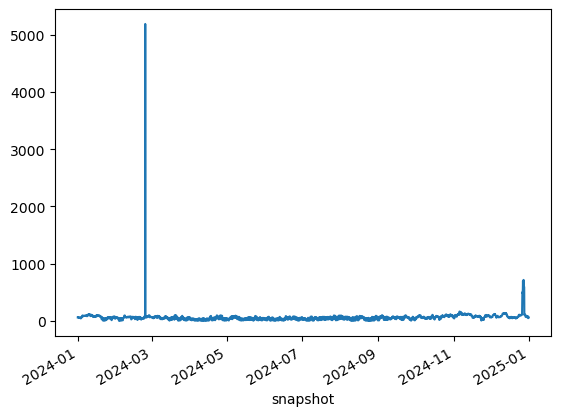

In [8]:
gb = n.buses.index[n.buses.carrier == 'AC']
hn.buses_t.marginal_price[gb].mean(axis=1).plot()

<Axes: xlabel='snapshot'>

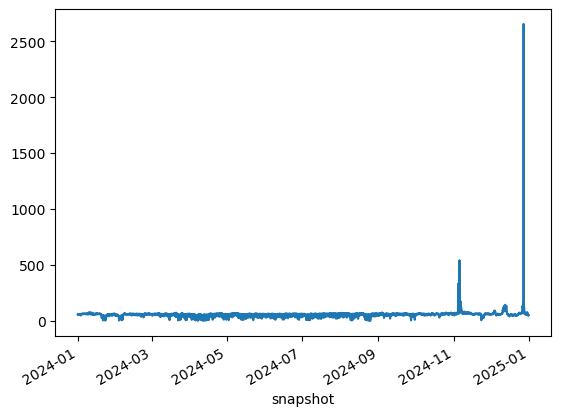

In [9]:
n.buses_t.marginal_price[gb].mean(axis=1).plot()

In [4]:
df['normal_total'] = df['normal_opex'] + df['normal_capex']
df['hike_total'] = df['hike_opex'] + df['hike_capex']

df['diff_total'] = df['hike_total'] - df['normal_total']

In [5]:
df

,wiggle,normal_opex,normal_capex,hike_opex,hike_capex,diff_opex,diff_capex,normal_total,hike_total,diff_total
0,500,449.268430,491.064273,497.614804,500.057554,48.346374,8.993281,940.332703,997.672358,57.339655
1,1250,455.611266,457.537410,534.997866,463.283719,79.386600,5.746309,913.148676,998.281585,85.132909
2,2000,467.547484,429.772896,581.707640,434.598259,114.160156,4.825364,897.320380,1016.305899,118.985520
3,2750,485.898606,405.008918,639.577777,409.718758,153.679171,4.709840,890.907524,1049.296534,158.389010
4,3500,505.199603,386.252845,696.180472,392.036502,190.980869,5.783657,891.452448,1088.216974,196.764526


In [40]:
capex_diff = (n.statistics.energy_balance() - hn.statistics.energy_balance())
print(capex_diff.sort_values().head(10))
print(capex_diff.sort_values().tail(10))

component  carrier                         bus_carrier         
Generator  oil primary                     oil primary            -3.992236e+08
Link       oil refining                    oil                    -3.790372e+08
           urban decentral oil boiler      urban decentral heat   -2.478195e+08
           lignite                         lignite                -1.165732e+08
           coal                            coal                   -1.037048e+08
           urban decentral biomass boiler  solid biomass          -1.001116e+08
           rural oil boiler                rural heat             -9.332648e+07
           electricity distribution grid   AC                     -8.208072e+07
           urban decentral oil boiler      co2                    -7.079377e+07
           rural biomass boiler            solid biomass          -6.339305e+07
dtype: float64
component  carrier                         bus_carrier         
Link       urban decentral biomass boiler  urban decentra

In [42]:
n.buses_t.marginal_price[gb].head()

Bus,AL0 0,AT0 0,BA0 0,BE0 0,BG0 0,CH0 0,CZ0 0,DE0 0,DE0 1,DE0 2,...,NL0 0,NO1 0,PL0 0,PT0 0,RO0 0,RS0 0,SE1 0,SI0 0,SK0 0,XK0 0
snapshot,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,64.615710,68.593071,67.127595,25.897790,68.502371,69.784592,65.876067,33.738619,58.137161,10.159989,...,14.239121,47.804846,56.610140,72.527571,67.861929,67.041788,50.718570,67.758011,66.257750,66.247208
2024-01-01 03:00:00,64.615634,68.593054,67.127072,27.536264,68.633126,69.784751,65.876125,42.857747,59.349423,26.864869,...,24.563630,47.804843,61.398114,72.527575,67.861974,67.049051,50.718573,67.758751,66.260472,66.146233
2024-01-01 06:00:00,64.615343,67.507497,67.127919,39.443807,68.500029,69.784696,66.374080,48.637863,61.667328,39.236815,...,26.732099,47.804856,64.570388,72.527631,67.759944,67.101845,50.718586,67.488135,66.812816,66.276912
2024-01-01 09:00:00,58.871273,57.302434,61.806434,44.271425,60.577927,57.077023,61.376726,50.102032,55.734683,45.371999,...,37.671767,47.804862,62.628983,54.679648,62.629835,62.469297,50.718588,62.041847,62.073320,59.800546
2024-01-01 12:00:00,58.870557,56.936954,61.033866,46.139938,59.716065,57.750891,60.280351,50.100906,55.810679,45.046477,...,41.695793,47.804863,62.628987,54.387598,62.632884,61.877440,50.718591,60.564741,61.325345,59.802774


In [43]:
hn.buses_t.marginal_price[gb].head()

Bus,AL0 0,AT0 0,BA0 0,BE0 0,BG0 0,CH0 0,CZ0 0,DE0 0,DE0 1,DE0 2,...,NL0 0,NO1 0,PL0 0,PT0 0,RO0 0,RS0 0,SE1 0,SI0 0,SK0 0,XK0 0
snapshot,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,60.441573,59.813447,62.516491,22.673348,63.207737,59.767951,58.171196,30.164878,48.576398,12.356624,...,13.793005,40.220326,48.682130,61.100278,62.869556,62.678531,42.240920,61.731896,60.462184,62.259205
2024-01-01 03:00:00,60.405653,59.813815,62.516517,22.674480,63.237029,59.745906,58.529757,30.410739,48.645276,14.228920,...,15.817239,40.220308,51.815766,61.100274,62.869423,62.617176,42.240785,61.732886,60.464465,62.176267
2024-01-01 06:00:00,60.403625,59.816164,62.516497,22.677903,63.206692,59.744031,58.922188,36.151367,50.607565,22.110118,...,14.686188,40.220322,56.495603,61.100380,62.831664,62.617428,42.240929,61.729273,60.473141,62.177959
2024-01-01 09:00:00,49.848073,48.260354,53.694201,25.675206,51.333830,48.341912,51.441520,36.261182,48.647806,25.038870,...,16.930550,40.220330,56.240183,45.810711,54.850332,54.001861,42.240946,52.066559,52.240315,51.496195
2024-01-01 12:00:00,49.845074,47.724197,53.702568,26.967350,51.319559,48.334728,52.474842,36.262396,48.644978,24.847479,...,19.248746,40.220337,56.240129,45.809009,54.904424,54.005059,42.240963,51.997881,52.443778,51.507403


(0.0, 200.0)

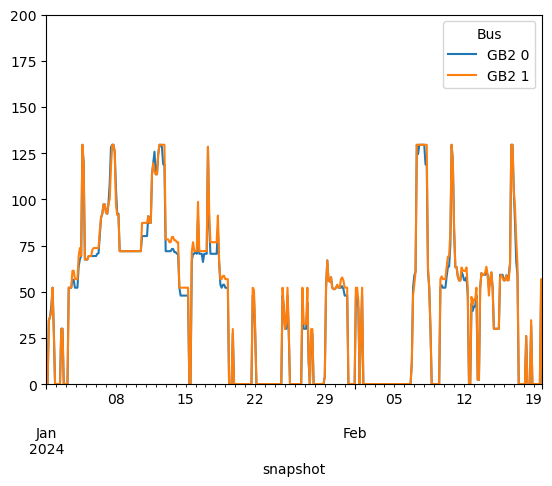

In [30]:
n.buses_t.marginal_price[['GB2 0', 'GB2 1']].head(400).plot()
plt.ylim(0, 200)

In [32]:
gb = n.buses.index[n.buses.carrier == 'AC']
mp = n.buses_t.marginal_price[gb].where(n.buses_t.marginal_price[gb] <= 1000)
vals = mp.std().astype(int).sort_values()

gaspower = eb.loc[idx[:, ['Combined-Cycle Gas', 'Open-Cycle Gas'], gb, 'AC']]
gaspower = gaspower.groupby(level=2).sum()

data = pd.DataFrame({'gaspower': gaspower, 'std': vals})
data


,gaspower,std
AL0 0,1.358513e+02,32
AT0 0,4.696580e+05,38
BA0 0,1.447126e+02,33
BE0 0,4.611319e+06,63
BG0 0,1.400190e+02,32
CH0 0,8.821797e+03,56
CZ0 0,3.488803e+05,52
DE0 0,8.067517e+05,44
DE0 1,5.921728e+05,47
DE0 2,4.198942e+06,49


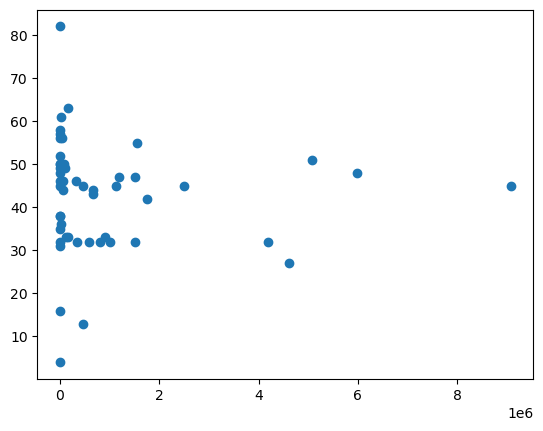

In [33]:
plt.scatter(gaspower, vals)